##### **Create a Model who will Evaluate the Essay and suggest feedback if not up to the mark**

In [1]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict
from pydantic import BaseModel

load_dotenv()

True

In [2]:
from typing import Annotated, Literal, List
from operator import add
from pydantic import Field


class EssaySchema(TypedDict):
    topic: str
    essay: str
    feedback: Annotated[List[str], add]= Field(description='make records of all the feedback ')
    status: Literal['Approved', 'Need Improvement']
    iterator: int
    max_iterator: int


class EvaluatorSchema(BaseModel):
    feedback:str=Field(description='Evaluate an Essay and Generate a Feedback based on the given Essay')

class StatusSchema(BaseModel):
    status: Literal['Approved', 'Need Improvement']


In [3]:
llm_model = ChatOpenAI(model='gpt-4-0613')
llm_model_with_schema_evaluator = llm_model.with_structured_output(EvaluatorSchema)
llm_model_with_schema_score = llm_model.with_structured_output(StatusSchema)

c:\Users\test\Desktop\LangGraph\Practice\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:2181: UserWarning: Cannot use method='json_schema' with model gpt-4-0613 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [ ]:
def generator(state: EssaySchema):
    topic = state['topic']
    prompt = f'Write a simple and esay Kindagarden level essay on the given Topic, use childish langugae, do some grammetical mistakes , spelling mistake, low rated essay: {topic}'

    essay = llm_model.invoke(prompt).content
    return {'essay':essay}


def evaluator_clarity(state: EssaySchema):
    essay = state['essay']
    topic = state['topic']
    prompt = f'Evaluate the Below essay on the basis of Clarity of Thought on the given topic:\nTopic:{topic}\nEssay:{essay}'
    response = llm_model_with_schema_evaluator.invoke(prompt)

    return {'feedback':state['feedback'] + [response.feedback]}


def evaluator_understanding(state: EssaySchema):
    essay = state['essay']
    topic = state['topic']
    prompt = f'Evaluate the Below essay on the basis on the Understanding on the given topic:\nTopic:{topic}\nEssay:{essay}'
    response = llm_model_with_schema_evaluator.invoke(prompt)

    return {'feedback':state['feedback'] + [response.feedback]}

def evaluator_language(state: EssaySchema):
    essay = state['essay']
    topic = state['topic']
    prompt = f'Evaluate the Below essay on the basis of Language and Grammer used in the essay on the given topic:\nTopic:{topic}\nEssay:{essay}'
    response = llm_model_with_schema_evaluator.invoke(prompt)

    return {'feedback':state['feedback'] + [response.feedback]}

def final_evaluator(state: EssaySchema):
    feedback = state['feedback']
    prompt = f'''
You are a strict evaluator for Government Job Exam essays.

Your task is to evaluate the essay by carefully considering the feedback provided. 
Judge the essay based on the following qualities:
- Professional appearance
- Depth of understanding
- Logical thought process
- Analytical ability required to crack a Government Job exam

Feedback to consider:
{feedback}

Evaluation Instructions:
1. Carefully analyze whether the essay reflects the corrections or expectations mentioned in the feedback.
2. Check if the essay demonstrates strong conceptual understanding and structured thinking.
3. The essay should appear professional, well-organized, and exam-ready.
4. If the essay fails to address any major feedback point, shows weak reasoning, or lacks clarity, it should NOT be approved.
5. Be strict in your evaluation.

Output Rules:
- If the essay satisfies the feedback and shows strong professional quality → **Approved**
- If the essay fails to satisfy the feedback or lacks depth/clarity → **Need Improvement**

Final Output Format:
Decision: Approved
or
Decision: Need Improvement
'''
    response = llm_model_with_schema_score.invoke(prompt)

    return {'status':response.status}


def check_condition(state:EssaySchema):
    status = state['status']
    iterator = state['iterator']
    max_iterator = state['max_iterator']
    if status=='Need Improvement' and iterator<=max_iterator:
        return "optimizer"
    else:
        return "END"


def optimizer(state: EssaySchema):
    print('inside optimizer')
    feedback = state['feedback']
    iterator = state['iterator']
    prompt = f'''Optimized the Essay Based on the given Feedback: {feedback}'''
    essay = llm_model.invoke(prompt).content
    iterator = iterator +1

    return {'essay':essay , 'iterator':iterator}

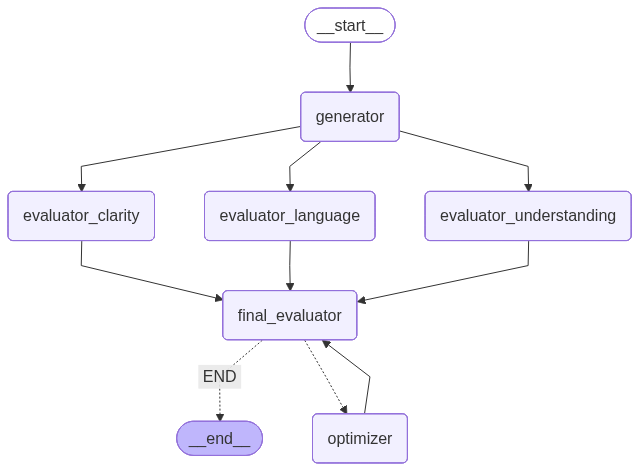

In [5]:
graph = StateGraph(EssaySchema)

## Add Node
graph.add_node('generator', generator) ## Take topic Generate Essay
graph.add_node('evaluator_clarity', evaluator_clarity) ## Take Essay evaluate on COT generate feedback
graph.add_node('evaluator_understanding', evaluator_understanding) ## Take Essay evaluate on Deep Understanding generate feedback 
graph.add_node('evaluator_language', evaluator_language) ## Take Essay evaluate on Language and generate feedback
graph.add_node('final_evaluator', final_evaluator)  ## it will take all the feedback and give final approval or Improvements
graph.add_node('optimizer', optimizer) ## Take feedback and update the Essay


## Add Edges
graph.add_edge(START, 'generator')
graph.add_edge("generator", 'evaluator_clarity')
graph.add_edge("generator", 'evaluator_understanding')
graph.add_edge("generator", 'evaluator_language')
graph.add_edge('evaluator_clarity', 'final_evaluator')
graph.add_edge('evaluator_understanding', 'final_evaluator')
graph.add_edge('evaluator_language', 'final_evaluator')
graph.add_conditional_edges('final_evaluator', check_condition, {'optimizer':'optimizer','END':END})
graph.add_edge('optimizer', 'final_evaluator')


## Graph Compile
final_graph = graph.compile()

final_graph

In [ ]:
initial_state = {
    "topic": "My Father",
    "essay": "",
    "feedback": [],
    'status': '',
    'iterator': 0,
    'max_iterator':2
}

response = final_graph.invoke(initial_state)
response

KeyboardInterrupt: 

In [ ]:
print(len(response['feedback']))

3
